In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

linwid = 0.5; fontSize = 22; fontSize2 = 26; yoko = 6;tate = 5.5

mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
})

In [3]:
def generate_weights(N=10, spectral_radius=0.9, max_real_part=None, seed=0):
    rng = np.random.default_rng(seed)

    A = rng.normal(size=(N, N))
    B = rng.normal(size=N) * 0.1

    eigvals = np.linalg.eigvals(A)
    
    if max_real_part is not None:
        current_max_real = np.max(np.real(eigvals))
        scale = max_real_part / current_max_real if abs(current_max_real) > 1e-10 else 1.0
        A = A * scale
    else:
        current_rho = np.max(np.abs(eigvals))
        scale = spectral_radius / current_rho if current_rho > 1e-10 else 1.0
        A = A * scale

    return A, B

In [ ]:
#generate input series
input_M = 1        
NUM_SAMPLES = 1010000 
input_mat = np.random.uniform(-1.0, 1.0, size=(NUM_SAMPLES, input_M))

input_mat_bin = input_mat.astype(np.float64)

filename = f"input_1.01e6.bin"
with open(filename, "wb") as f:
    input_mat_bin.T.tofile(f)

In [5]:
N_size = 100
A_fixed, B_fixed = generate_weights(N_size, spectral_radius = 0.5, seed = 10)

In [ ]:
#run reservoir 

def run_quadratic_system_vectorized(input_series, A, B, x0=None, transient=1000, buff = 10000, noise_std=0.01, save_path=None):
    N = A.shape[0]
    total_steps = len(input_series) - buff + transient
    
    T = total_steps - transient
    
    states = np.zeros((T, 1 + N))
    states[:, 0] = 1.0

    x_prev = x0 if x0 is not None else np.zeros(N)

    idx = 0
    for t in range(total_steps):
        noise = np.random.normal(0, noise_std, size=N)
        
        x_curr = A @ x_prev - (x_prev**2) + B * input_series[t + buff - transient] + noise
        
        if t >= transient:
            states[idx, 1:] = x_curr
            idx += 1
        
        x_prev = x_curr

    if save_path is not None:
        states.astype(np.float64).T.tofile(save_path)

    return states

In [7]:
noise_std = 0.0005
x = run_quadratic_system_vectorized(
        input_mat[:1010000],A=A_fixed,B=B_fixed,x0 = None,transient = 1000,buff = 10000,
        noise_std = noise_std,
        save_path=f"stateData_quadsys_{noise_std:.4f}_1.01e6.bin")

[9.59843599]


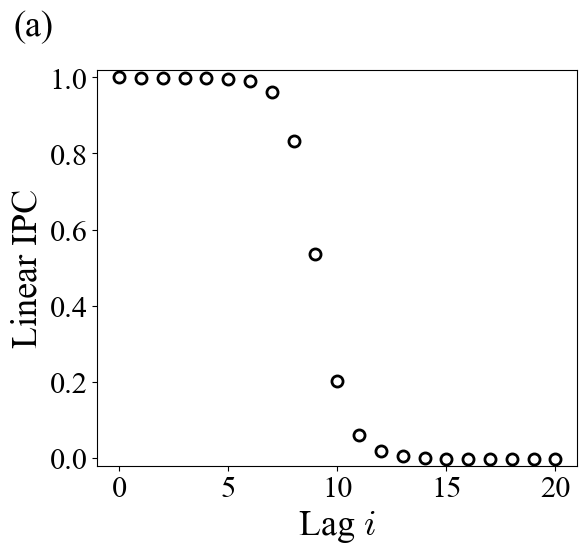

In [4]:
#visualize information processing capacity 

degree = 6; delaymax = 21
capacities = np.zeros((degree, 1))

filename = "output_est_IPC_quadsys_0.0005_1.01e6.txt"
M = np.genfromtxt(filename, delimiter="\t")
condition = (M[:, degree] == 1) & (M[:, degree + 1] == 0)
indices = np.where(condition)[0]

cap_1 = M[indices, 2 * degree]

yRange = [-0.02, 1.02]
xRange = [-1, delaymax]

fig = plt.figure(figsize=(yoko, tate))
fig.subplots_adjust(left=0.15,    right=0.95,    bottom=0.15,   top=0.87  )
axs = plt.gca()
axs.plot(cap_1, color='k', linestyle = 'none', marker = 'o', markersize = 8, markeredgewidth=2, markerfacecolor='w')
axs.set_ylim(yRange)
axs.set_xlim(xRange)
axs.tick_params(axis='both', which='major', labelsize=fontSize)
axs.set_ylabel('Linear IPC', fontsize=fontSize2)
axs.set_xlabel(r"Lag $i$", fontsize=fontSize2)

sum_above_threshold = cap_1[cap_1 >= 0].sum()
text = 'Linear, ' + f'sum={sum_above_threshold: .2f}'
capacities[0] = sum_above_threshold

print(capacities[0])

fig.text(0.01, 0.98, '(a)',fontsize=fontSize2,ha='left',va='top')

plt.savefig("test.pdf")
plt.show()

1.00064
[30.56993236]


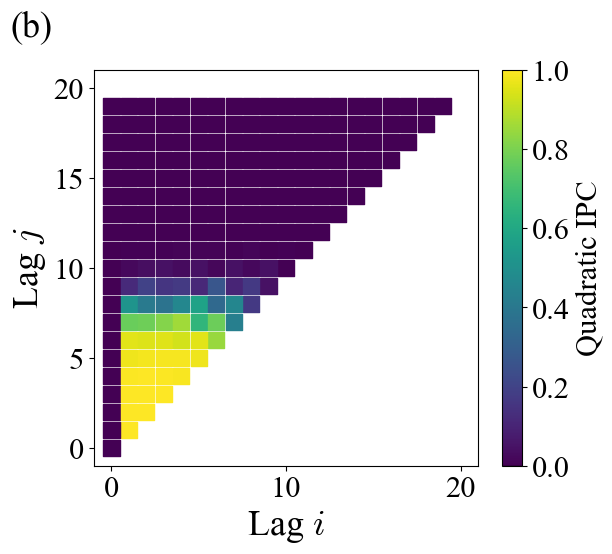

In [ ]:
cond2 = (M[:, degree] == 2) & (M[:, degree + 1] == 0)
idx2 = np.where(cond2)[0]
cap_2 = M[idx2, 2 * degree] if idx2.size > 0 else np.array([])
di2 = np.array(M[idx2, 0]) if idx2.size > 0 else np.array([])
dj2 = np.array(M[idx2, 0]) if idx2.size > 0 else np.array([])

cond3 = (M[:, degree] == 1) & (M[:, degree + 1] == 1) & (M[:, degree + 2] == 0)
idx3 = np.where(cond3)[0]
cap_3 = M[idx3, 2 * degree] if idx3.size > 0 else np.array([])
di3 = np.array(M[idx3, 0]) if idx3.size > 0 else np.array([])
dj3 = np.array(M[idx3, 1]) if idx3.size > 0 else np.array([])

cap_4 = np.concatenate((cap_2, cap_3))

delay_i = np.concatenate((di2, di3))
delay_j = np.concatenate((dj2, dj3)) 

cap_4_plotted = np.copy(cap_4)
cap_4_plotted[cap_4_plotted < 0] = 0.0

vmin = min(cap_4_plotted)
vmax = 1
t_pos = 1e-5
col_step = (1 - t_pos) / 4
cmap = 'viridis'
fig = plt.figure(figsize=(yoko, tate))
fig.subplots_adjust(left=0.15,right=0.95,bottom=0.15,top=0.87)   
sc = plt.scatter(delay_i, delay_j, c=cap_4_plotted, marker = 's', cmap=cmap, vmin=vmin, vmax=vmax, s=135)
axs = plt.gca()
cb = plt.colorbar(sc)

cb.ax.tick_params(labelsize = fontSize)
cb.set_label(label='Quadratic IPC', fontsize=fontSize)
axs.tick_params(axis='both', which='major', labelsize=fontSize)
sum_above_threshold = cap_4[cap_4 >= 0].sum()
capacities[1] = sum_above_threshold

cb.ax.hlines(y=0, xmin=0, xmax=1, colors='k',linestyle = '-',linewidth=1.0, transform=cb.ax.transData)
axs.set_xlim([-1, delaymax])
axs.set_ylim([-1, delaymax])
plt.xlabel('Lag ' + '$i$', fontsize = fontSize2)
plt.ylabel('Lag ' + '$j$', fontsize = fontSize2)
print(max(cap_4))
print(capacities[1])

fig.text(0.01, 0.98, '(b)',fontsize=fontSize2,ha='left',va='top')
plt.savefig("test2.pdf")
plt.show()

In [ ]:
for i in range (0,degree):
    cond4 = np.sum(M[:, degree : degree + degree], axis = 1) == i + 1
    idx4 = np.where(cond4)[0]
    cap_4 = M[idx4, 2 * degree] if idx4.size > 0 else np.array([])
   
    mask = cap_4 >= 0
    sum_above_threshold = cap_4[mask].sum()
    print(f'd={i + 1}, sum={sum_above_threshold}')
   
    capacities[i] = sum_above_threshold

capacities_test = capacities
print(np.sum(capacities_test))
  

d=1, sum=9.59843599
d=2, sum=30.569932362019998
d=3, sum=41.5407885405
d=4, sum=14.610070188249999
d=5, sum=1.0175294222
d=6, sum=0.0111424081
97.34789891106999


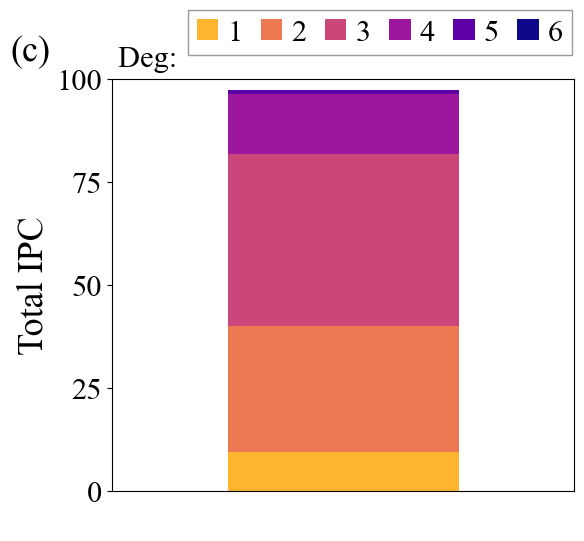

In [ ]:
capacities = np.array([capacities_test.flatten()])
capacities = capacities.T  
bar_wid = 0.75

x_ref = np.linspace(0, 10, 300)
y_ref = 10 / (1 + x_ref)

labels = [f'Estimated IPC']
x = np.arange(len(labels))  
fig = plt.figure(figsize=(yoko, tate))
fig.subplots_adjust(left=0.18, right=0.95, bottom=0.15, top=0.9)
ax = plt.gca()
bottom = np.zeros(len(x))
cmap = plt.colormaps.get_cmap('plasma').reversed()
colors = [cmap((i + 1)/ (capacities.shape[0])) for i in range(capacities.shape[0])]

for i in range(capacities.shape[0]):
    ax.bar(x, capacities[i], bottom=bottom, color=colors[i], label=f'{i+1}', width=bar_wid)
    bottom += capacities[i]

ax.set_xticks([])
ax.set_xlim(0 - bar_wid, len(x)-1 + bar_wid)
ax.set_ylim(0, max(100, np.sum(capacities_test)))
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_ylabel("Total IPC", fontsize = fontSize2)
ax.set_xlabel(" ", fontsize = fontSize2)
ax.legend(fontsize = fontSize, edgecolor = 'gray', facecolor = 'None', fancybox=False, 
          title_fontsize = fontSize, loc='lower center', bbox_to_anchor=(0.58, 1.02),
          ncol=capacities_test.shape[0], columnspacing=0.6, handletextpad=0.3, handlelength=0.7, borderpad=0.3, labelspacing=0.3)

fig.text(
    0.19, 0.96,
    "Deg: ",
    fontsize=fontSize,ha='left',va='top'
)
fig.text(0.01, 0.98, '(c)',fontsize=fontSize2,ha='left',va='top')
ax.tick_params(axis='both', which='major', labelsize=fontSize)

plt.savefig("test3.pdf")